In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('train_data.csv')
df.drop(columns=['index', 'State'], axis=1, errors='ignore')
# Drop non-numeric or timestamp columns if present
data = df.select_dtypes(include=['float64', 'int64'])
data.head()

,index,S1_AN3,S1_AN4,S1_AN5,S1_AN6,S1_AN7,S1_AN8,S1_AN9,S1_AN10,S1_Speed,State
0,0,-0.823841,0.749480,-2.316878,-1.960000,4.391394,-3.048822,-2.294245,-0.485538,0.000585,1
1,1,-1.402680,0.977488,-2.939493,-1.525210,3.927973,-3.260050,-2.718662,0.146392,0.000578,1
2,2,-2.122453,-0.224492,-3.292221,2.777935,-0.730244,-1.523624,-3.092139,0.415281,0.000628,1
3,3,-2.693342,0.305910,-3.057404,2.147219,-0.410198,-2.144959,-3.407326,-0.016563,0.000608,1
4,4,-2.670948,1.539633,-2.402231,0.788547,-1.330330,-2.612996,-3.614957,0.060899,0.000606,1


In [12]:
# Normalize features
features = data.columns
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[features[1:-1]])
data_scaled

array([[-0.37277941,  0.32078822, -0.72705516, ..., -0.39315731,
        -0.15671357, -1.00009484],
       [-0.63879384,  0.41707136, -0.93269462, ..., -0.47417654,
         0.05199067, -1.00009485],
       [-0.9695771 , -0.09050065, -1.04919476, ..., -0.54547146,
         0.1407955 , -1.00009479],
       ...,
       [-2.44578893,  0.88176548,  0.63415056, ..., -2.00088334,
        -0.89609155,  0.99880954],
       [-2.83182563,  0.51893387,  1.20532675, ..., -1.44765453,
        -0.36766688,  0.99867651],
       [-3.02859699,  0.36793362,  1.19825431, ..., -1.23862834,
         0.14300884,  0.99866187]])

In [16]:

# Isolation Forest model
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(data_scaled)

# Label: 1 = normal, -1 = anomaly
df['is_anomaly'] = df['anomaly'] == -1

# Print number of anomalies
print(f"Total anomalies found: {df['is_anomaly'].sum()}")


Total anomalies found: 1000


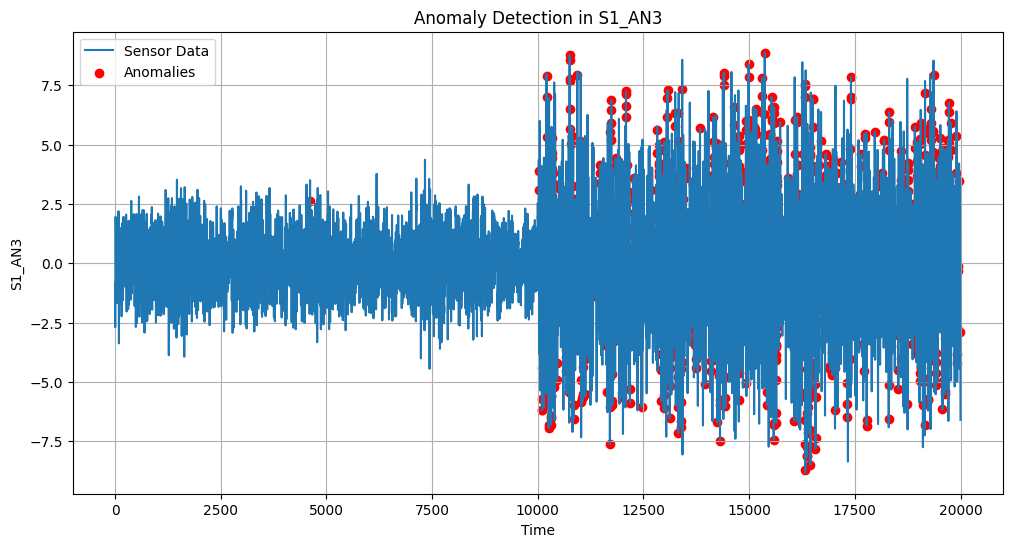

In [19]:
# Plotting (example for 1 feature)
feature = data.columns[1]
plt.figure(figsize=(12, 6))
plt.plot(df[feature], label='Sensor Data')
plt.scatter(df[df['is_anomaly']].index, df[df['is_anomaly']][feature], color='red', label='Anomalies')
plt.title(f'Anomaly Detection in {feature}')
plt.xlabel('Time')
plt.ylabel(feature)
plt.legend()
plt.grid(True)
plt.show()

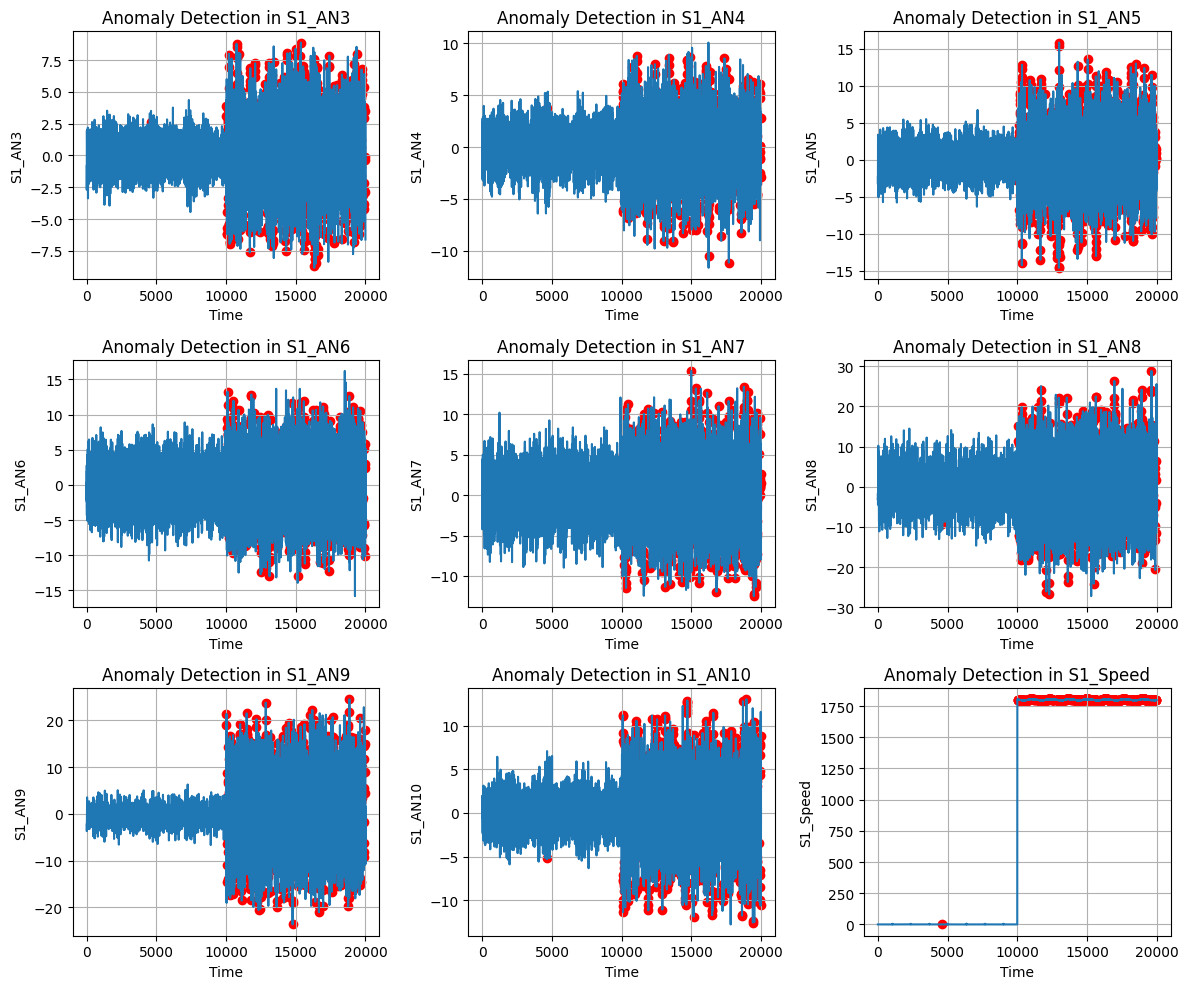

In [35]:
# Create 3x3 subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 10))  # 3 rows, 3 cols

# Flatten the 2D array of axes for easy iteration
axes = axes.flatten()

featuresToPlot = features[1:-1]
dataToPlot = data[featuresToPlot]

# Plot into each subplot
for i in range(0, len(featuresToPlot)):
    y = dataToPlot[featuresToPlot[i]]  # example variation
    axes[i].plot(df[featuresToPlot[i]], label='Sensor Data')
    axes[i].scatter(df[df['is_anomaly']].index, df[df['is_anomaly']][featuresToPlot[i]], color='red', label='Anomalies')
    axes[i].set_title(f'Anomaly Detection in {featuresToPlot[i]}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel(featuresToPlot[i])
    axes[i].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()